# Claims Frequency Forecasting
End-to-end pipeline: raw EDA → feature engineering → model building & selection.

**Target**: `claim_count` per (`Coverage Type`, `Region`, `year_month`)  
**Models**: Poisson GLM, Negative Binomial GLM, LightGBM  
**Split**: temporal — train ≤2023-06 | val 2023-07–12 | test 2024

## 1. Setup

In [ ]:
%pip install openpyxl statsmodels lightgbm -q

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('muted')

EXCEL_PATH = r"C:\Users\DorothyCheruiyot\Desktop\Projects\insurance_claims\data\insurance_data_features.xlsx"

---
## 2. Raw EDA
Explore the raw sheets before any feature engineering.

### 2.1 Load & join raw sheets

In [17]:
xl        = pd.read_excel(EXCEL_PATH, sheet_name=None)
claims    = xl['Claims'].copy()
customers = xl['Customers'].copy()
external  = xl['External'].copy()

print(f"Claims    : {claims.shape}    columns: {list(claims.columns)}")
print(f"Customers : {customers.shape}  columns: {list(customers.columns)}")
print(f"External  : {external.shape}   columns: {list(external.columns)}")

Claims    : (5000, 11)    columns: ['Claim Id', 'Policy Id', 'Customer Id', 'Claim Date', 'Claim Type', 'Claim Amount', 'Claim Status', 'Settlement Days', 'Settlement Date', 'Fraud Flag', 'Coverage Type']
Customers : (10000, 12)  columns: ['Customer Id', 'Age', 'Gender', 'Region', 'Income Band', 'Tenure Years', 'Credit Score', 'Payment Pattern', 'Late Payments 12M', 'Prior Claims Count', 'Occupation', 'Postcode District']
External  : (1800, 10)   columns: ['Region', 'Year Month', 'Avg Rainfall Mm', 'Avg Wind Speed Kmh', 'Flood Risk Index', 'Gdp Growth Rate', 'Cpi Inflation', 'Unemployment Rate', 'Avg Property Price Gbp', 'Storm Event Flag']


In [18]:
claims['Claim Date'] = pd.to_datetime(claims['Claim Date'])
claims['year_month'] = claims['Claim Date'].dt.to_period('M').astype(str)

raw = claims.merge(customers, on='Customer Id', how='left')
raw = raw.merge(external.rename(columns={'Year Month': 'year_month'}), on=['Region', 'year_month'], how='left')

print(f"Joined dataset: {raw.shape}")
print(f"Date range    : {raw['Claim Date'].min().date()} → {raw['Claim Date'].max().date()}")
raw.head()

Joined dataset: (5000, 31)
Date range    : 2021-01-13 → 2024-12-31


,Claim Id,Policy Id,Customer Id,Claim Date,Claim Type,Claim Amount,Claim Status,Settlement Days,Settlement Date,Fraud Flag,...,Occupation,Postcode District,Avg Rainfall Mm,Avg Wind Speed Kmh,Flood Risk Index,Gdp Growth Rate,Cpi Inflation,Unemployment Rate,Avg Property Price Gbp,Storm Event Flag
0,CLM0000001,POL001589,CUST04742,2021-02-28,Accident,3070.31,Settled,118,2021-06-26,0,...,Diplomatic Services operational officer,ST7R,30.4,11.5,1.83,0.0115,0.0631,0.0539,328500,0
1,CLM0000002,POL010598,CUST09209,2024-07-18,Medical,2668.14,Settled,83,2024-10-09,0,...,Data scientist,CW4N,78.5,20.5,3.55,0.0113,0.0406,0.0443,280400,0
2,CLM0000003,POL002080,CUST01646,2022-11-16,Accident,19384.22,Settled,116,2023-03-12,0,...,Logistics and distribution manager,HR3,17.4,13.0,1.00,0.0099,0.0385,0.0345,219700,1
3,CLM0000004,POL006528,CUST09866,2021-06-13,Theft,3965.53,Settled,13,2021-06-26,0,...,"Programme researcher, broadcasting/film/video",W9 3,63.0,16.6,3.02,0.0195,0.0328,0.0374,357000,0
4,CLM0000005,POL006798,CUST07857,2024-10-27,Medical,2170.25,Pending,139,2025-03-15,0,...,Quarry manager,M11,58.6,11.0,2.78,0.0076,0.0643,0.0355,252000,0


### 2.2 Overview — dtypes & missing values

In [19]:
summary = pd.DataFrame({
    'dtype':    raw.dtypes,
    'non_null': raw.notnull().sum(),
    'missing':  raw.isnull().sum(),
    'missing%': (raw.isnull().mean() * 100).round(2),
    'nunique':  raw.nunique(),
})
display(summary)

,dtype,non_null,missing,missing%,nunique
Claim Id,str,5000,0,0.0,5000
Policy Id,str,5000,0,0.0,4334
Customer Id,str,5000,0,0.0,3527
Claim Date,datetime64[us],5000,0,0.0,1359
Claim Type,str,5000,0,0.0,7
Claim Amount,float64,5000,0,0.0,4878
Claim Status,str,5000,0,0.0,3
Settlement Days,int64,5000,0,0.0,174
Settlement Date,datetime64[us],5000,0,0.0,1382
Fraud Flag,int64,5000,0,0.0,2


### 2.3 Claim status & fraud

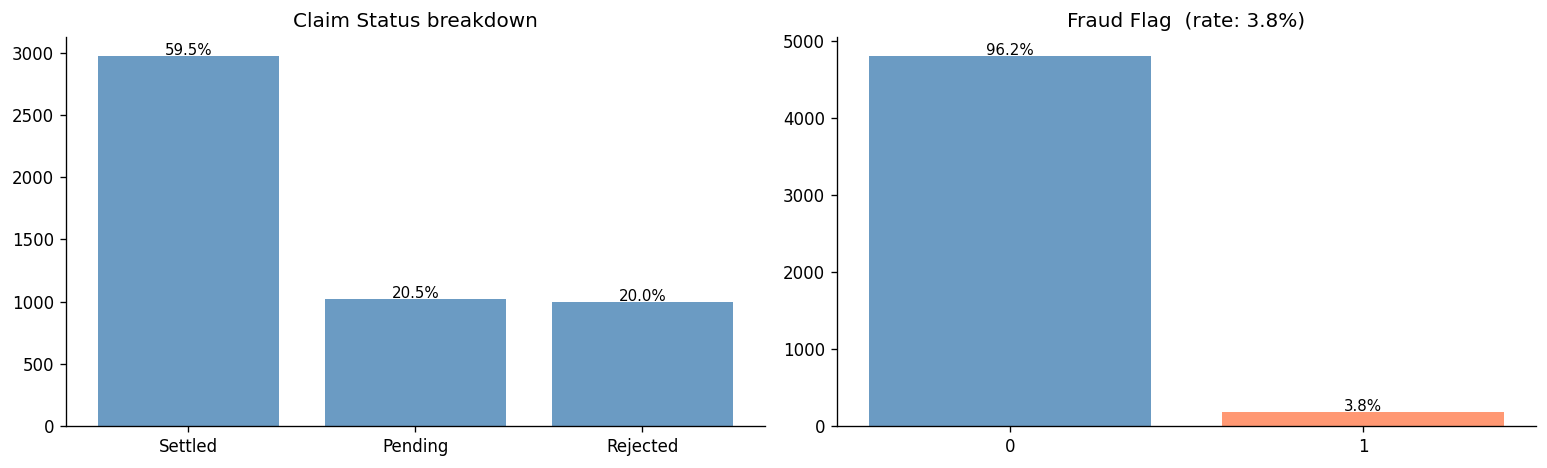

→ Pending claims and fraud-flagged rows will be excluded from the training target.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

status_vc = raw['Claim Status'].value_counts()
axes[0].bar(status_vc.index, status_vc.values, color='steelblue', alpha=0.8)
axes[0].set_title('Claim Status breakdown')
for i, (k, v) in enumerate(status_vc.items()):
    axes[0].text(i, v + 5, f'{v/len(raw)*100:.1f}%', ha='center', fontsize=9)

fraud_vc = raw['Fraud Flag'].value_counts()
axes[1].bar(fraud_vc.index.astype(str), fraud_vc.values, color=['steelblue', 'coral'], alpha=0.8)
axes[1].set_title(f'Fraud Flag  (rate: {raw["Fraud Flag"].mean()*100:.1f}%)')
for i, (k, v) in enumerate(fraud_vc.items()):
    axes[1].text(i, v + 5, f'{v/len(raw)*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("→ Pending claims and fraud-flagged rows will be excluded from the training target.")

### 2.4 Claim volume by coverage type & region

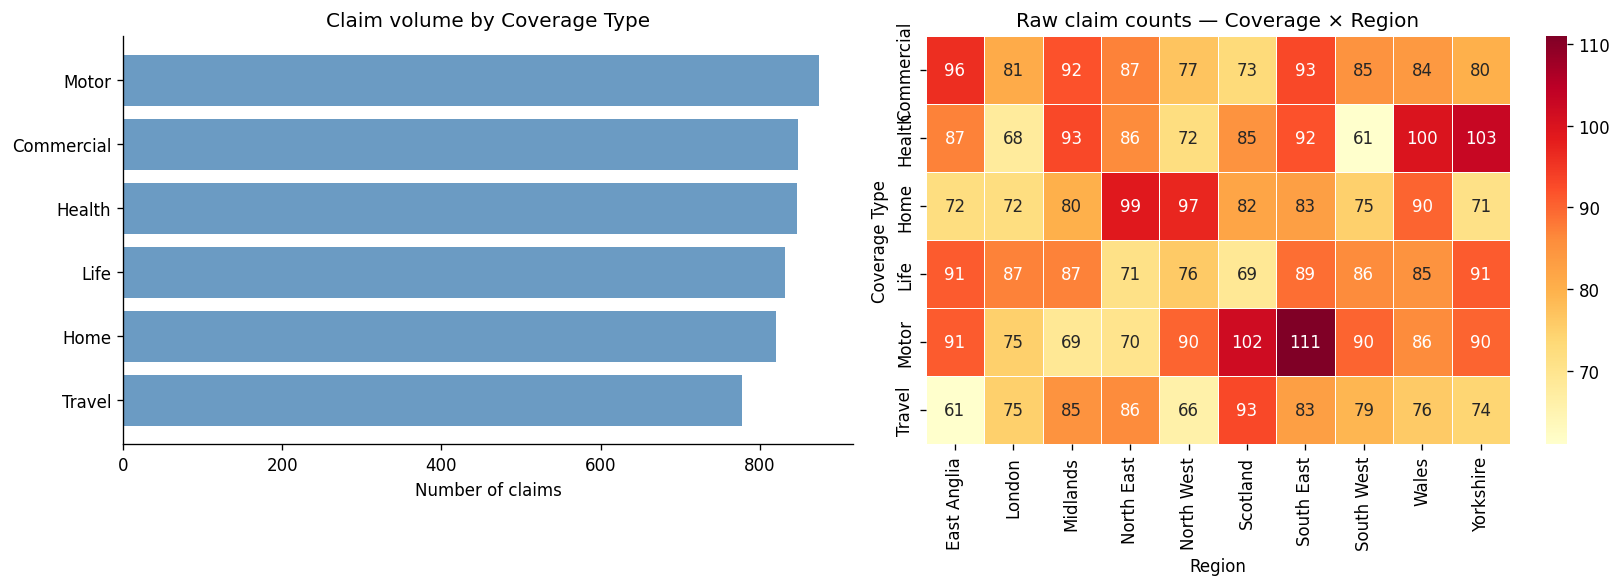

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cov_counts = raw['Coverage Type'].value_counts().sort_values()
axes[0].barh(cov_counts.index, cov_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Claim volume by Coverage Type')
axes[0].set_xlabel('Number of claims')

pivot_raw = raw.groupby(['Coverage Type', 'Region']).size().unstack(fill_value=0)
sns.heatmap(pivot_raw, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Raw claim counts — Coverage × Region')

plt.tight_layout()
plt.show()

### 2.5 Time patterns

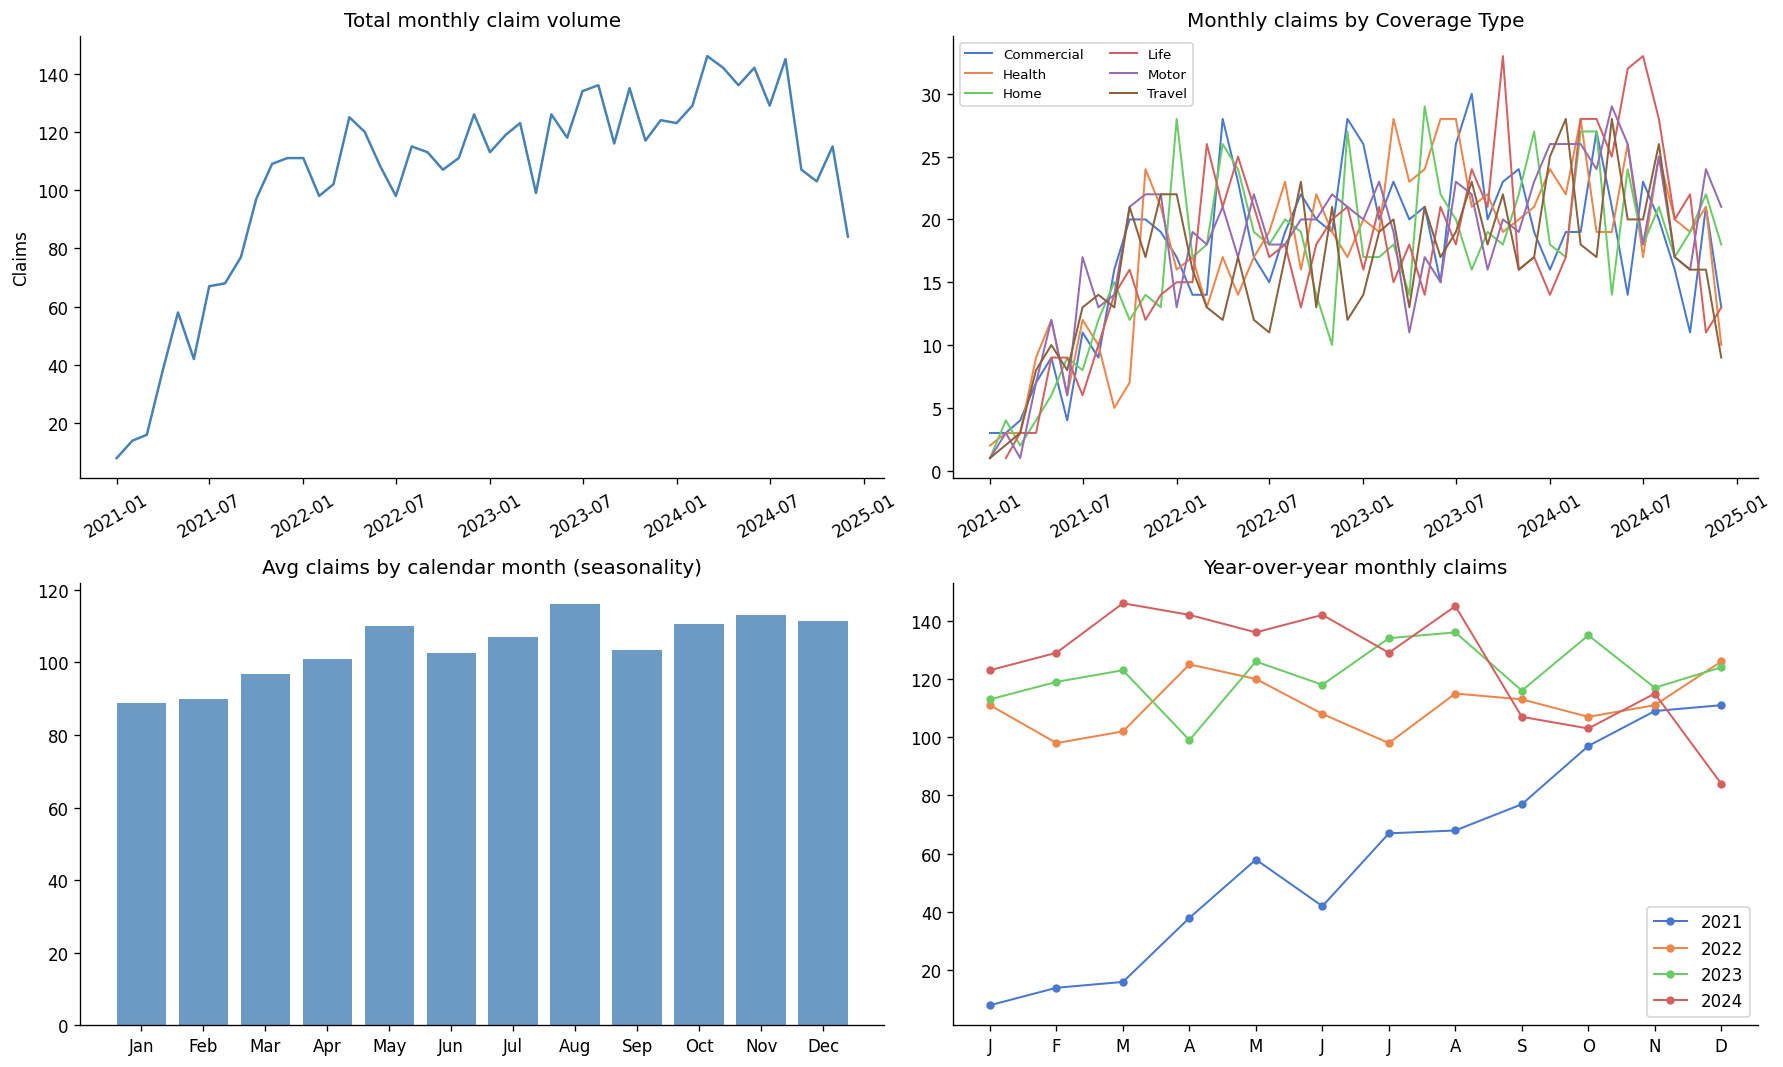

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

monthly = raw.groupby('year_month').size().reset_index(name='n')
monthly['ym_dt'] = pd.to_datetime(monthly['year_month'])

axes[0,0].plot(monthly['ym_dt'], monthly['n'], color='steelblue', linewidth=1.5)
axes[0,0].set_title('Total monthly claim volume')
axes[0,0].set_ylabel('Claims')
axes[0,0].tick_params(axis='x', rotation=30)

cov_monthly = raw.groupby(['year_month', 'Coverage Type']).size().reset_index(name='n')
cov_monthly['ym_dt'] = pd.to_datetime(cov_monthly['year_month'])
for cov, grp in cov_monthly.groupby('Coverage Type'):
    axes[0,1].plot(grp['ym_dt'], grp['n'], label=cov, linewidth=1.2)
axes[0,1].set_title('Monthly claims by Coverage Type')
axes[0,1].legend(fontsize=8, ncol=2)
axes[0,1].tick_params(axis='x', rotation=30)

raw['month_num'] = raw['Claim Date'].dt.month
month_avg = raw.groupby('month_num').size() / raw['Claim Date'].dt.year.nunique()
axes[1,0].bar(month_avg.index, month_avg.values, color='steelblue', alpha=0.8)
axes[1,0].set_xticks(range(1, 13))
axes[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1,0].set_title('Avg claims by calendar month (seasonality)')

yoy = raw.groupby([raw['Claim Date'].dt.year, 'month_num']).size().reset_index(name='n')
yoy.columns = ['year', 'month_num', 'n']
for yr, grp in yoy.groupby('year'):
    axes[1,1].plot(grp['month_num'], grp['n'], marker='o', ms=4, label=str(yr), linewidth=1.2)
axes[1,1].set_xticks(range(1, 13))
axes[1,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].set_title('Year-over-year monthly claims')
axes[1,1].legend()

plt.tight_layout()
plt.show()

### 2.6 External features

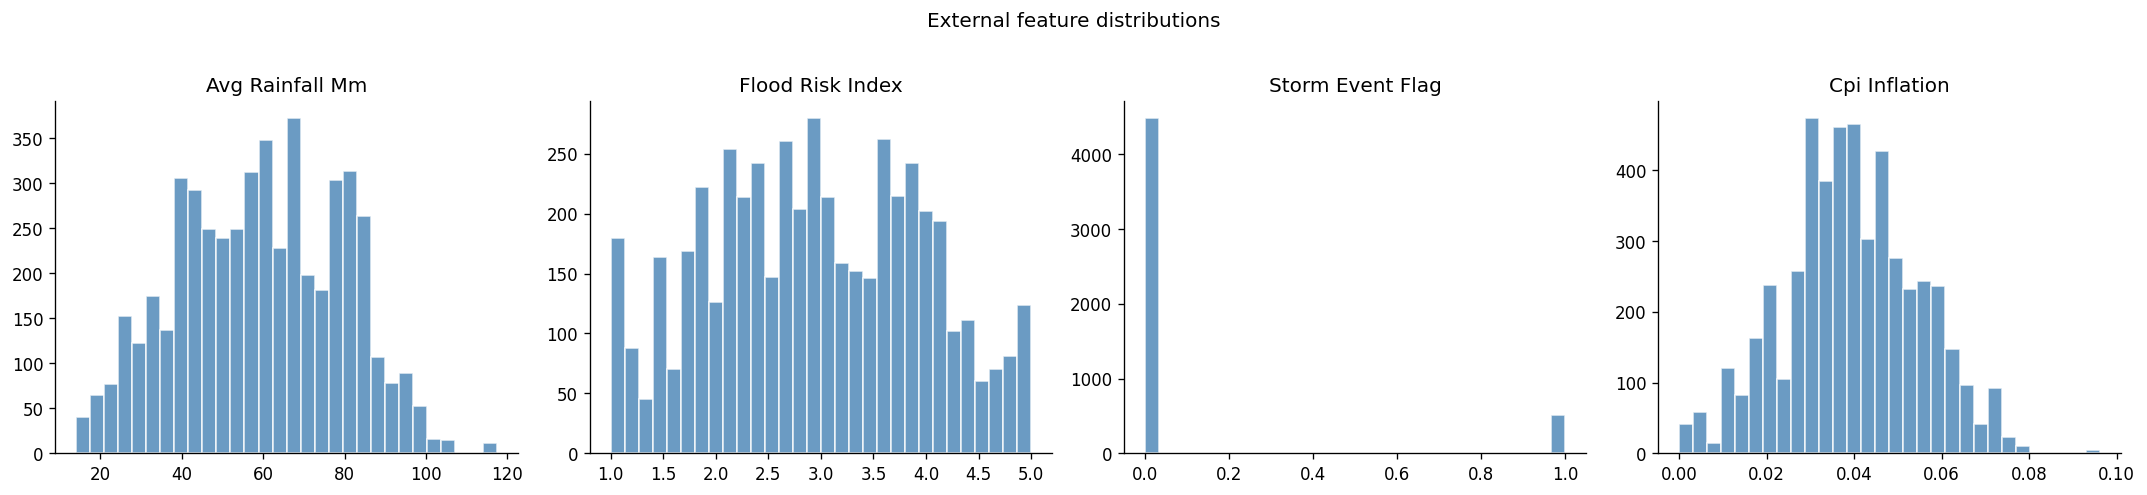

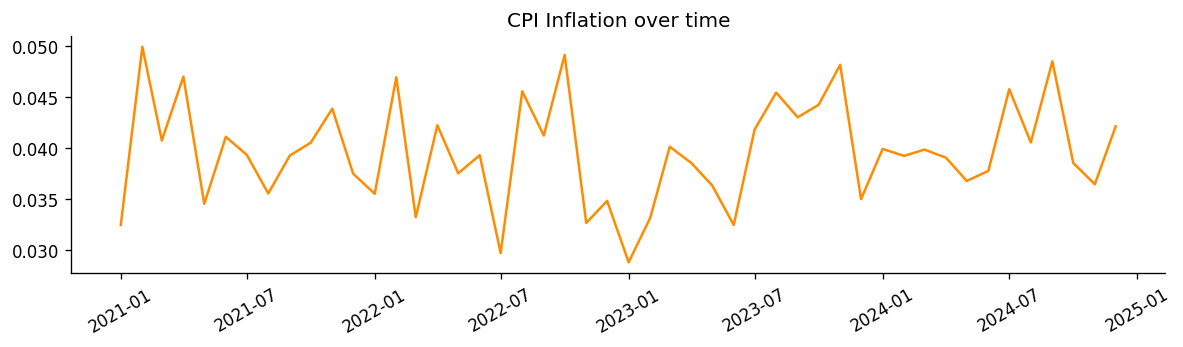

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['Avg Rainfall Mm', 'Flood Risk Index', 'Storm Event Flag', 'Cpi Inflation']):
    ax.hist(raw[col].dropna(), bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(col)
plt.suptitle('External feature distributions', y=1.02)
plt.tight_layout()
plt.show()

# CPI trend
cpi = raw.groupby('year_month')['Cpi Inflation'].mean().reset_index()
cpi['ym_dt'] = pd.to_datetime(cpi['year_month'])
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(cpi['ym_dt'], cpi['Cpi Inflation'], color='darkorange', linewidth=1.5)
ax.set_title('CPI Inflation over time')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 3. Data Preparation & Feature Engineering

### 3.1 Build claim count grid

In [24]:
xl        = pd.read_excel(EXCEL_PATH, sheet_name=None)
claims    = xl['Claims'].copy()
customers = xl['Customers'].copy()
external  = xl['External'].copy()

# Bring region onto claims
claims = claims.merge(customers[['Customer Id', 'Region']], on='Customer Id', how='left')

# Exclude pending and fraud
claims = claims[claims['Claim Status'] != 'Pending']
claims = claims[claims['Fraud Flag'] == 0]

claims['Claim Date'] = pd.to_datetime(claims['Claim Date'])
claims['year_month'] = claims['Claim Date'].dt.to_period('M').astype(str)

claim_counts = (
    claims.groupby(['Coverage Type', 'Region', 'year_month'])
    .size()
    .reset_index(name='claim_count')
)

# Full grid — all coverage × region × month (zero-claim months included)
months = pd.period_range('2021-01', '2024-12', freq='M').astype(str)
full_grid = pd.MultiIndex.from_product(
    [claims['Coverage Type'].unique(), customers['Region'].unique(), months],
    names=['Coverage Type', 'Region', 'year_month']
).to_frame(index=False)

df = full_grid.merge(claim_counts, on=['Coverage Type', 'Region', 'year_month'], how='left')
df['claim_count'] = df['claim_count'].fillna(0).astype(int)

print(f'Grid shape : {df.shape}  (expected 6 × 10 × 48 = {6*10*48})')
print(f'Zero rows  : {(df["claim_count"] == 0).sum():,}')
df['claim_count'].describe()

Grid shape : (2880, 4)  (expected 6 × 10 × 48 = 2880)
Zero rows  : 879


count    2880.000000
mean        1.325000
std         1.267846
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: claim_count, dtype: float64

### 3.2 Time features

In [25]:
period = pd.PeriodIndex(df['year_month'], freq='M')
df['year']      = period.year
df['month']     = period.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['t']         = (period - period.min()).map(lambda x: x.n)

df[['year_month', 'year', 'month', 'month_sin', 'month_cos', 't']].head()

,year_month,year,month,month_sin,month_cos,t
0,2021-01,2021,1,0.500000,8.660254e-01,0
1,2021-02,2021,2,0.866025,5.000000e-01,1
2,2021-03,2021,3,1.000000,6.123234e-17,2
3,2021-04,2021,4,0.866025,-5.000000e-01,3
4,2021-05,2021,5,0.500000,-8.660254e-01,4


### 3.3 Lag features

In [26]:
df = df.sort_values(['Coverage Type', 'Region', 'year_month']).reset_index(drop=True)
grp = df.groupby(['Coverage Type', 'Region'])['claim_count']

df['lag_1']      = grp.shift(1)
df['lag_3']      = grp.shift(3)
df['lag_12']     = grp.shift(12)
df['roll3_mean'] = grp.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

print(f'NaNs from lag_12 (expected — first 12 months per segment): {df["lag_12"].isna().sum()}')
df[['year_month', 'claim_count', 'lag_1', 'lag_3', 'lag_12', 'roll3_mean']].head(15)

NaNs from lag_12 (expected — first 12 months per segment): 720


,year_month,claim_count,lag_1,lag_3,lag_12,roll3_mean
0,2021-01,0,NaN,NaN,NaN,NaN
1,2021-02,1,0.0,NaN,NaN,0.000000
2,2021-03,0,1.0,NaN,NaN,0.500000
3,2021-04,2,0.0,0.0,NaN,0.333333
4,2021-05,0,2.0,1.0,NaN,1.000000
5,2021-06,0,0.0,0.0,NaN,0.666667
6,2021-07,0,0.0,2.0,NaN,0.666667
7,2021-08,0,0.0,0.0,NaN,0.000000
8,2021-09,3,0.0,0.0,NaN,0.000000
9,2021-10,3,3.0,0.0,NaN,1.000000


### 3.4 External features

In [27]:
ext_cols = ['Region', 'Year Month', 'Avg Rainfall Mm', 'Flood Risk Index',
            'Storm Event Flag', 'Cpi Inflation']
ext = external[ext_cols].rename(columns={'Year Month': 'year_month'})
df  = df.merge(ext, on=['Region', 'year_month'], how='left')

print(f'Shape after external join: {df.shape}')
print('External NaNs:', df[['Avg Rainfall Mm', 'Flood Risk Index', 'Storm Event Flag', 'Cpi Inflation']].isna().sum().to_dict())

Shape after external join: (2880, 17)
External NaNs: {'Avg Rainfall Mm': 0, 'Flood Risk Index': 0, 'Storm Event Flag': 0, 'Cpi Inflation': 0}


### 3.5 Categorical encoding

In [28]:
df['coverage_enc'] = df['Coverage Type'].astype('category').cat.codes
df['region_enc']   = df['Region'].astype('category').cat.codes

print('Coverage encoding:')
print(df[['Coverage Type', 'coverage_enc']].drop_duplicates().sort_values('coverage_enc').to_string(index=False))
print('\nRegion encoding:')
print(df[['Region', 'region_enc']].drop_duplicates().sort_values('region_enc').to_string(index=False))

Coverage encoding:
Coverage Type  coverage_enc
   Commercial             0
       Health             1
         Home             2
         Life             3
        Motor             4
       Travel             5

Region encoding:
     Region  region_enc
East Anglia           0
     London           1
   Midlands           2
 North East           3
 North West           4
   Scotland           5
 South East           6
 South West           7
      Wales           8
  Yorkshire           9


---
## 4. EDA on Prepared Dataset

### 4.1 Target distribution & overdispersion

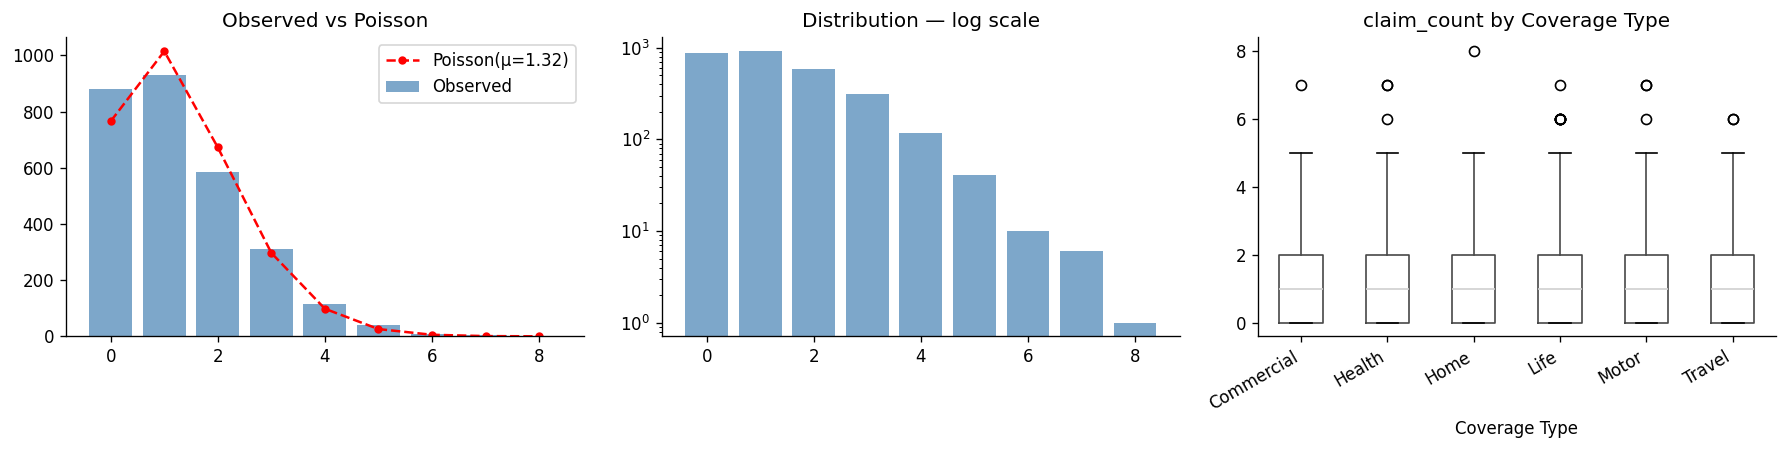

Mean     : 1.3250
Variance : 1.6074
Var/Mean : 1.2132  ← >1 suggests overdispersion
Zero %   : 30.5%


In [29]:
y = df['claim_count']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = y.value_counts().sort_index()
mu = y.mean()
x  = np.arange(0, y.max() + 1)
poisson_pmf = stats.poisson.pmf(x, mu) * len(df)

axes[0].bar(counts.index, counts.values, color='steelblue', alpha=0.7, label='Observed')
axes[0].plot(x, poisson_pmf, 'r--o', ms=4, label=f'Poisson(μ={mu:.2f})')
axes[0].set_title('Observed vs Poisson')
axes[0].legend()

axes[1].bar(counts.index, counts.values, color='steelblue', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title('Distribution — log scale')

df.boxplot(column='claim_count', by='Coverage Type', ax=axes[2], grid=False)
axes[2].set_title('claim_count by Coverage Type')
plt.suptitle('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

var_mean  = y.var() / y.mean()
zero_pct  = (y == 0).mean() * 100
print(f"Mean     : {y.mean():.4f}")
print(f"Variance : {y.var():.4f}")
print(f"Var/Mean : {var_mean:.4f}  ← >1 suggests overdispersion")
print(f"Zero %   : {zero_pct:.1f}%")

In [30]:
# Cameron & Trivedi overdispersion test
aux_y = ((y - mu)**2 - y) / mu
aux_x = mu * np.ones(len(y))
slope, intercept, r, p, se = stats.linregress(aux_x, aux_y)

print("=== Overdispersion Test ===")
print(f"  Var/Mean ratio : {var_mean:.4f}")
print(f"  C&T aux slope  : {slope:.4f}  (p = {p:.4f})")
if var_mean > 1.1 and p < 0.05:
    print("→ Overdispersion confirmed — NegBin worth testing alongside Poisson")
else:
    print("→ Mild/no overdispersion — Poisson is the primary model")

ValueError: Cannot calculate a linear regression if all x values are identical

### 4.2 Segment-level means & heatmap

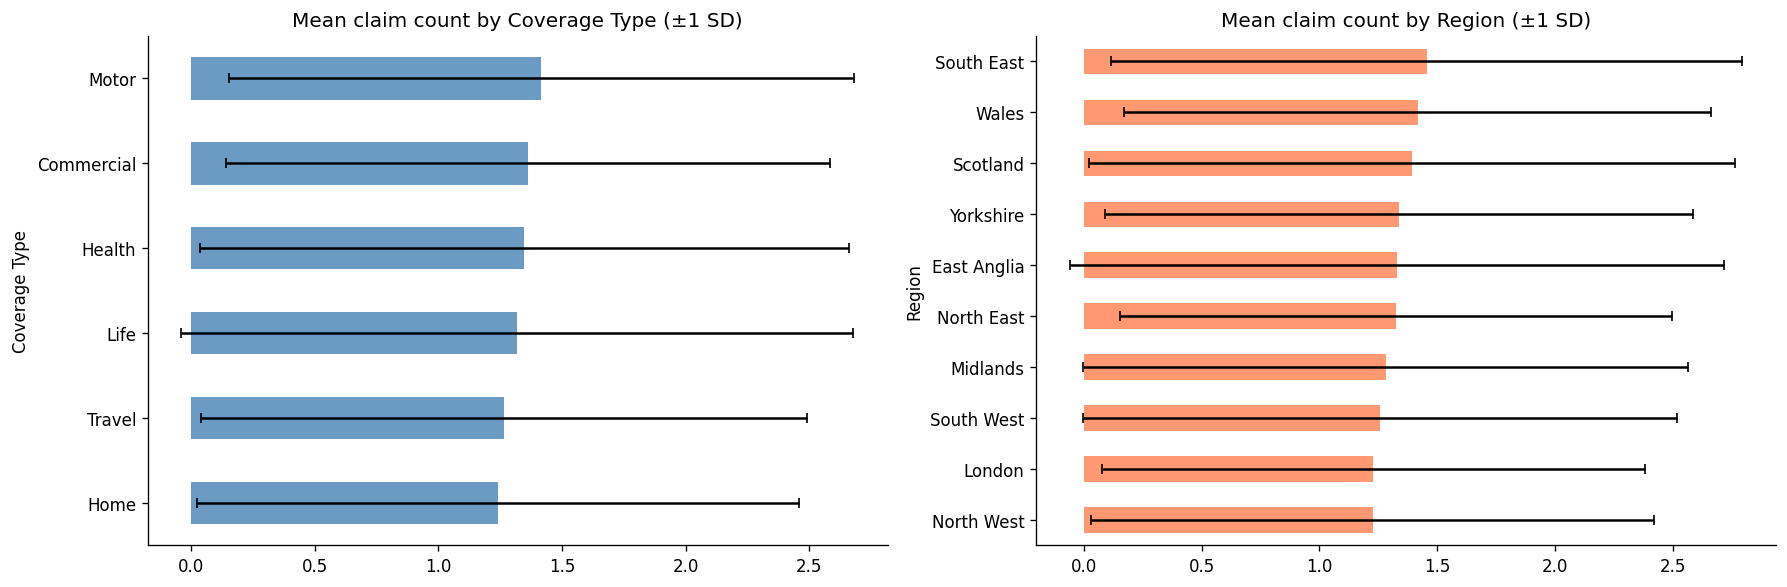

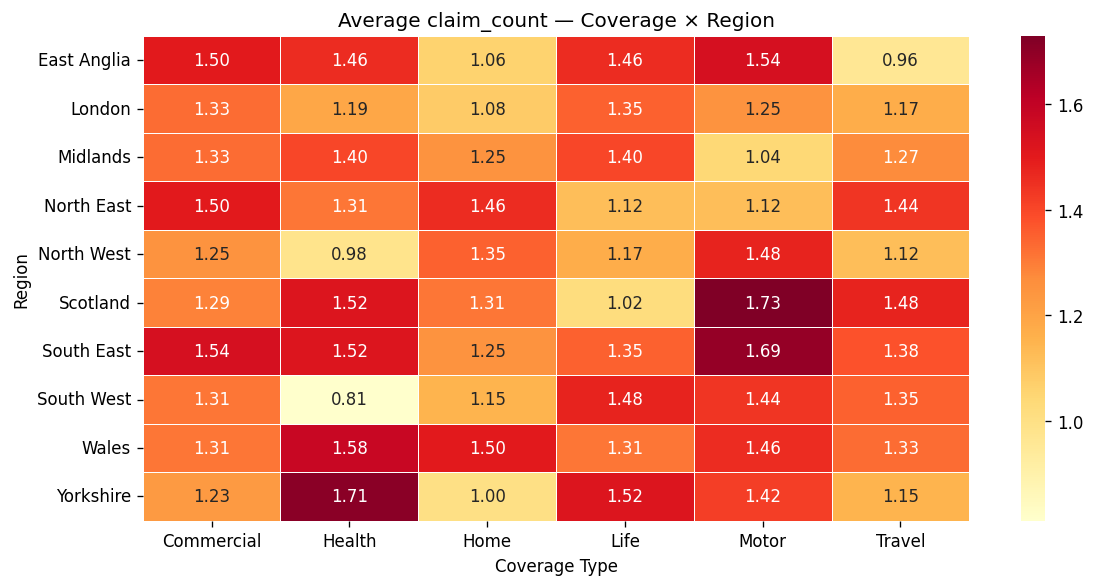

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cov_stats = df.groupby('Coverage Type')['claim_count'].agg(['mean', 'std'])
cov_stats.sort_values('mean', ascending=True).plot.barh(
    y='mean', xerr='std', ax=axes[0], legend=False, color='steelblue', alpha=0.8, capsize=3)
axes[0].set_title('Mean claim count by Coverage Type (±1 SD)')

reg_stats = df.groupby('Region')['claim_count'].agg(['mean', 'std'])
reg_stats.sort_values('mean', ascending=True).plot.barh(
    y='mean', xerr='std', ax=axes[1], legend=False, color='coral', alpha=0.8, capsize=3)
axes[1].set_title('Mean claim count by Region (±1 SD)')
plt.tight_layout()
plt.show()

pivot = df.pivot_table(values='claim_count', index='Region', columns='Coverage Type', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot.round(2), annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Average claim_count — Coverage × Region')
plt.tight_layout()
plt.show()

### 4.3 Temporal trends

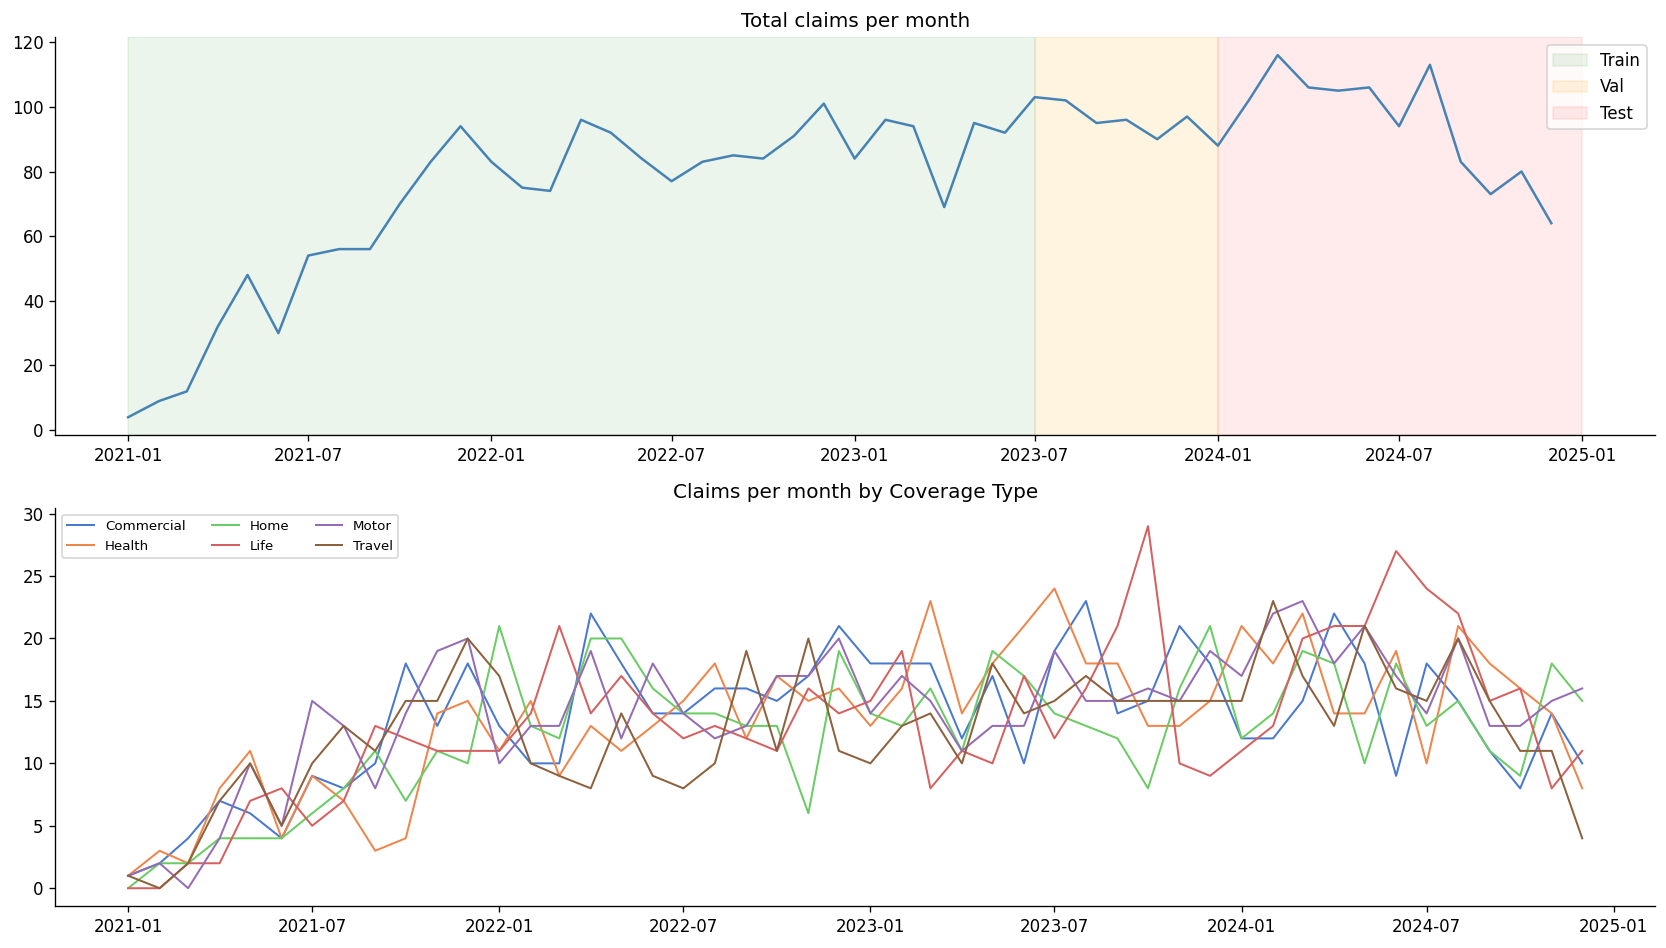

In [32]:
monthly = df.groupby('year_month')['claim_count'].sum().reset_index()
monthly['ym_dt'] = pd.to_datetime(monthly['year_month'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(monthly['ym_dt'], monthly['claim_count'], color='steelblue', linewidth=1.5)
ax.axvspan(pd.Timestamp('2021-01'), pd.Timestamp('2023-07'), alpha=0.08, color='green',  label='Train')
ax.axvspan(pd.Timestamp('2023-07'), pd.Timestamp('2024-01'), alpha=0.12, color='orange', label='Val')
ax.axvspan(pd.Timestamp('2024-01'), pd.Timestamp('2025-01'), alpha=0.08, color='red',    label='Test')
ax.set_title('Total claims per month')
ax.legend()

ax = axes[1]
cov_monthly = df.groupby(['year_month', 'Coverage Type'])['claim_count'].sum().reset_index()
cov_monthly['ym_dt'] = pd.to_datetime(cov_monthly['year_month'])
for cov, grp in cov_monthly.groupby('Coverage Type'):
    ax.plot(grp['ym_dt'], grp['claim_count'], label=cov, linewidth=1.2)
ax.set_title('Claims per month by Coverage Type')
ax.legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

### 4.4 Feature correlations with target

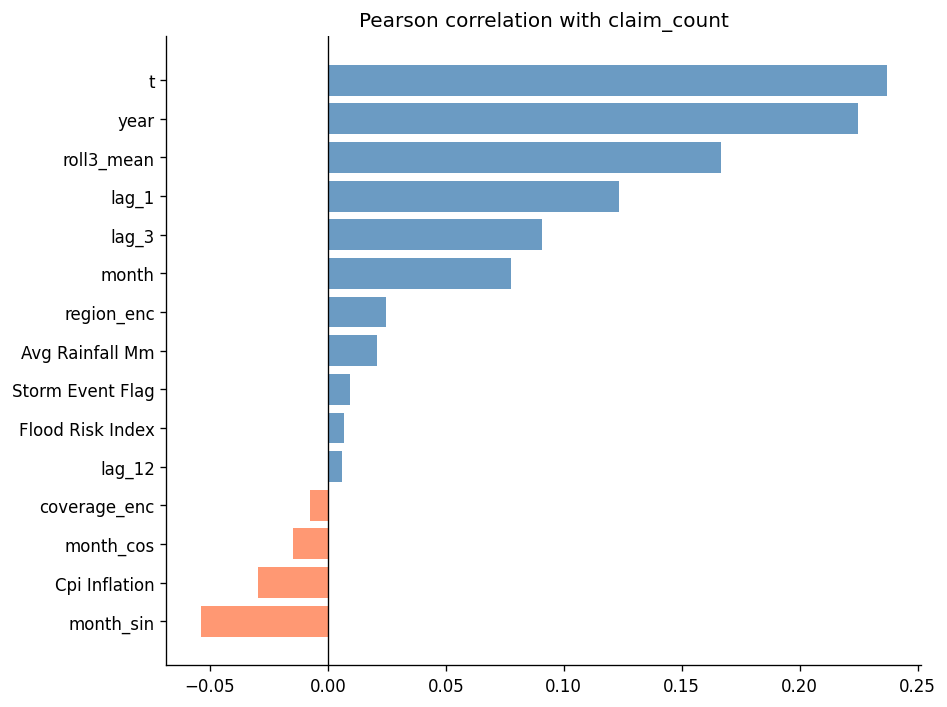

In [33]:
FEATURES = ['year', 'month', 'month_sin', 'month_cos', 't',
            'lag_1', 'lag_3', 'lag_12', 'roll3_mean',
            'Avg Rainfall Mm', 'Flood Risk Index', 'Storm Event Flag', 'Cpi Inflation',
            'coverage_enc', 'region_enc']

corr = df[FEATURES + ['claim_count']].corr()['claim_count'].drop('claim_count').sort_values()
colors = ['coral' if v < 0 else 'steelblue' for v in corr]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(corr.index, corr.values, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with claim_count')
plt.tight_layout()
plt.show()

---
## 5. Model Building & Selection

### 5.1 Train / val / test split (temporal)

In [34]:
train = df[df['year_month'] <= '2023-06'].dropna(subset=FEATURES).reset_index(drop=True)
val   = df[(df['year_month'] >= '2023-07') & (df['year_month'] <= '2023-12')].dropna(subset=FEATURES).reset_index(drop=True)
test  = df[df['year_month'] >= '2024-01'].dropna(subset=FEATURES).reset_index(drop=True)

print(f"Train : {len(train):,} rows  ({train['year_month'].min()} → {train['year_month'].max()})")
print(f"Val   : {len(val):,} rows  ({val['year_month'].min()} → {val['year_month'].max()})")
print(f"Test  : {len(test):,} rows  ({test['year_month'].min()} → {test['year_month'].max()})")

Train : 1,080 rows  (2022-01 → 2023-06)
Val   : 360 rows  (2023-07 → 2023-12)
Test  : 720 rows  (2024-01 → 2024-12)


### 5.2 Helper functions

In [35]:
def add_const(d):
    return sm.add_constant(d[FEATURES], has_constant='add')

X_train, X_val, X_test = add_const(train), add_const(val), add_const(test)
y_train, y_val, y_test = train['claim_count'], val['claim_count'], test['claim_count']


def metrics(y_true, y_pred, name):
    eps = 1e-8
    return {
        'Model':    name,
        'A/E':      round(np.sum(y_true) / np.sum(y_pred), 4),
        'Deviance': round(2 * np.sum(y_true * np.log((y_true + eps) / (y_pred + eps)) - (y_true - y_pred)), 2),
        'RMSE':     round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'MAE':      round(mean_absolute_error(y_true, y_pred), 4),
    }

def ae_by(df_seg, pred_col, group_col):
    return df_seg.groupby(group_col).apply(
        lambda x: round(x['claim_count'].sum() / x[pred_col].sum(), 3)
    ).rename('A/E')

### 5.3 Poisson GLM

In [36]:
results = []
test = test.copy()

glm_pois   = sm.GLM(y_train, X_train, family=sm.families.Poisson()).fit()
dispersion = np.sum((y_train - glm_pois.predict(X_train))**2 / glm_pois.predict(X_train)) /              (len(y_train) - len(glm_pois.params))

test['pred_pois'] = glm_pois.predict(X_test).values
results.append(metrics(y_val,  glm_pois.predict(X_val).values,  'Poisson GLM — Val'))
results.append(metrics(y_test, glm_pois.predict(X_test).values, 'Poisson GLM — Test'))

print(f"Dispersion: {dispersion:.3f} → {'NegBin warranted' if dispersion > 1 else 'Poisson ok'}")
print(glm_pois.summary())

Dispersion: 1.098 → NegBin warranted
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                 1080
Model:                            GLM   Df Residuals:                     1065
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1656.6
Date:                Fri, 22 May 2026   Deviance:                       1321.6
Time:                        07:29:45   Pearson chi2:                 1.17e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01566
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
con

### 5.4 Negative Binomial GLM

In [37]:
glm_nb = sm.GLM(y_train, X_train, family=sm.families.NegativeBinomial()).fit()

test['pred_nb'] = glm_nb.predict(X_test).values
results.append(metrics(y_val,  glm_nb.predict(X_val).values,  'NegBin GLM  — Val'))
results.append(metrics(y_test, glm_nb.predict(X_test).values, 'NegBin GLM  — Test'))
print("NegBin GLM fitted.")

NegBin GLM fitted.


### 5.5 LightGBM

In [38]:
lgb_train_ds = lgb.Dataset(train[FEATURES], label=y_train)
lgb_val_ds   = lgb.Dataset(val[FEATURES],   label=y_val, reference=lgb_train_ds)

model = lgb.train(
    {'objective': 'poisson', 'metric': 'poisson', 'num_leaves': 31,
     'learning_rate': 0.05, 'min_data_in_leaf': 5, 'verbose': -1},
    lgb_train_ds, num_boost_round=500, valid_sets=[lgb_val_ds],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)]
)

test['pred_lgb'] = model.predict(test[FEATURES])
results.append(metrics(y_val,  model.predict(val[FEATURES]),  'LightGBM    — Val'))
results.append(metrics(y_test, model.predict(test[FEATURES]), 'LightGBM    — Test'))
print("LightGBM fitted.")

LightGBM fitted.


### 5.6 Results

In [39]:
summary = pd.DataFrame(results)
ae_cov  = pd.DataFrame({'Poisson': ae_by(test,'pred_pois','Coverage Type'),
                        'NegBin':  ae_by(test,'pred_nb',  'Coverage Type'),
                        'LGB':     ae_by(test,'pred_lgb', 'Coverage Type')})
ae_reg  = pd.DataFrame({'Poisson': ae_by(test,'pred_pois','Region'),
                        'NegBin':  ae_by(test,'pred_nb',  'Region'),
                        'LGB':     ae_by(test,'pred_lgb', 'Region')})
coefs   = pd.DataFrame({'coef': glm_pois.params, 'std_err': glm_pois.bse,
                        'z': glm_pois.tvalues, 'p_value': glm_pois.pvalues,
                        'sig': glm_pois.pvalues.apply(
                            lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
                        }).round(4)
fi = pd.Series(model.feature_importance(importance_type='gain'), index=FEATURES)        .sort_values(ascending=False).rename_axis('Feature').reset_index(name='Importance')

print("=== MODEL SUMMARY ===")
display(summary)
print("\n=== A/E BY COVERAGE TYPE (Test) ===")
display(ae_cov)
print("\n=== A/E BY REGION (Test) ===")
display(ae_reg)
print("\n=== POISSON GLM COEFFICIENTS ===")
display(coefs)
print("\n=== LGB FEATURE IMPORTANCE ===")
display(fi)

=== MODEL SUMMARY ===


,Model,A/E,Deviance,RMSE,MAE
0,Poisson GLM — Val,1.0399,459.98,1.3466,1.0838
1,Poisson GLM — Test,0.9658,930.20,1.3397,1.0806
2,NegBin GLM — Val,1.0401,459.93,1.3465,1.0832
3,NegBin GLM — Test,0.9683,930.98,1.3403,1.0809
4,LightGBM — Val,1.0995,455.83,1.3400,1.0814
5,LightGBM — Test,1.0699,904.76,1.3150,1.0458



=== A/E BY COVERAGE TYPE (Test) ===


,Poisson,NegBin,LGB
Coverage Type,,,
Commercial,0.781,0.782,0.908
Health,0.956,0.959,1.097
Home,0.871,0.872,0.972
Life,1.083,1.086,1.178
Motor,1.124,1.128,1.189
Travel,1.008,1.010,1.080



=== A/E BY REGION (Test) ===


,Poisson,NegBin,LGB
Region,,,
East Anglia,0.840,0.845,0.927
London,0.967,0.973,1.029
Midlands,0.959,0.963,1.061
North East,1.013,1.018,1.132
North West,0.898,0.902,0.994
Scotland,0.968,0.969,1.068
South East,0.979,0.979,1.109
South West,0.822,0.821,0.913
Wales,1.240,1.243,1.406



=== POISSON GLM COEFFICIENTS ===


,coef,std_err,z,p_value,sig
const,0.0000,0.0000,0.8350,0.4037,
year,0.0001,0.0001,0.8882,0.3744,
month,0.0178,0.0129,1.3791,0.1679,
month_sin,0.0695,0.0623,1.1170,0.2640,
month_cos,0.0414,0.0560,0.7403,0.4591,
t,0.0063,0.0056,1.1308,0.2581,
lag_1,0.0294,0.0292,1.0096,0.3127,
lag_3,0.0483,0.0294,1.6463,0.0997,
lag_12,-0.0321,0.0243,-1.3196,0.1870,
roll3_mean,-0.0514,0.0621,-0.8280,0.4077,



=== LGB FEATURE IMPORTANCE ===


,Feature,Importance
0,Cpi Inflation,391.590816
1,Avg Rainfall Mm,264.372760
2,roll3_mean,151.162241
3,t,142.089087
4,Flood Risk Index,138.919921
5,lag_12,135.950469
6,coverage_enc,131.886710
7,month,97.285341
8,region_enc,85.354712
9,lag_3,81.420970


### 5.7 Save outputs

In [40]:
summary.to_csv('model_summary.csv', index=False)
ae_cov.to_csv('ae_by_coverage.csv')
ae_reg.to_csv('ae_by_region.csv')
coefs.to_csv('glm_coefficients.csv')
fi.to_csv('feature_importance.csv', index=False)
test[['Coverage Type','Region','year_month','claim_count','pred_pois','pred_nb','pred_lgb']].to_csv(
    'test_predictions.csv', index=False)
print("All outputs saved.")

All outputs saved.
